In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import bioframe
from gtfparse import read_gtf
from matplotlib.lines import Line2D
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Prepare promoter capture Hi-C interactions (Misfud et al.)

In [3]:
genes = read_gtf('/DATA/users/m.magnitov/genomes/gencode.v42.basic.annotation.gtf')
genes = genes[genes['feature'] == 'gene']
genes = genes[['seqname', 'start', 'end', 'gene_id', 'gene_name']]
genes.columns = ['chrom', 'start', 'end', 'gene_id', 'gene_name']
genes['gene_id'] = [x.split('.')[0] for x in genes['gene_id']]
genes.head()

INFO:root:Extracted GTF attributes: ['gene_id', 'gene_type', 'gene_name', 'level', 'tag', 'transcript_id', 'transcript_type', 'transcript_name', 'transcript_support_level', 'havana_transcript', 'exon_number', 'exon_id', 'hgnc_id', 'havana_gene', 'ont', 'protein_id', 'ccdsid', 'artif_dupl']


,chrom,start,end,gene_id,gene_name
0,chr1,11869,14409,ENSG00000290825,DDX11L2
5,chr1,12010,13670,ENSG00000223972,DDX11L1
13,chr1,14404,29570,ENSG00000227232,WASH7P
26,chr1,17369,17436,ENSG00000278267,MIR6859-1
29,chr1,29554,31109,ENSG00000243485,MIR1302-2HG


In [7]:
pchic = pd.read_csv('/DATA/users/m.magnitov/hap_phen/HiC/public_data/mifsud_pcHiC_GM12878_promoter-other_significant_interactions.txt', sep = '\t')
pchic = pchic[['Ensembl Gene ID', 'chr', 'start', 'end']]
pchic.head()

,Ensembl Gene ID,chr,start,end
0,ENSG00000008128|ENSG00000215790|ENSG0000022662...,chr1,1583927,1585571
1,ENSG00000064932|ENSG00000118046,chr19,1228423,1232133
2,ENSG00000102879|ENSG00000132207|ENSG0000016962...,chr16,30136787,30183514
3,ENSG00000169575|ENSG00000250086,chr22,22617806,22625547
4,ENSG00000100030|ENSG00000225544,chr22,22212576,22212652


In [29]:
pchic_interactions = []

for interaction in pchic.values:
    gene_ids_bait = interaction[0].split('|')
    
    for gene_id_bait in gene_ids_bait:
        if gene_id_bait in genes['gene_id'].values:
            pchic_interactions.append([gene_id_bait, interaction[1], interaction[2], interaction[3]])
        else:
            pass

pchic_interactions = pd.DataFrame(pchic_interactions, columns = ['gene_id', 'chrom_int', 'start_int', 'end_int'])
pchic_interactions = pchic_interactions.merge(genes[['gene_id', 'gene_name']], on = 'gene_id')
pchic_interactions = pchic_interactions.sort_values('gene_name')
pchic_interactions.head()

,gene_id,chrom_int,start_int,end_int,gene_name
1047613,ENSG00000148584,chr10,52577786,52579844,A1CF
1047603,ENSG00000148584,chr10,52712309,52714857,A1CF
1047605,ENSG00000148584,chr10,52612251,52615180,A1CF
1047606,ENSG00000148584,chr10,52458846,52463162,A1CF
1047607,ENSG00000148584,chr10,52718230,52719464,A1CF


In [32]:
pchic_interactions[['chrom_int', 'start_int', 'end_int', 'gene_id', 'gene_name']].to_csv('/DATA/users/m.magnitov/hap_phen/HiC/public_data/mifsud_pcHiC_interactions_GM12878_processed.bed', sep = '\t', header = 0, index = 0)

CrossMap.py bed /DATA/users/m.magnitov/genomes/hg19ToHg38.over.chain /DATA/users/m.magnitov/hap_phen/HiC/public_data/mifsud_pcHiC_interactions_GM12878_processed.bed /DATA/users/m.magnitov/hap_phen/HiC/public_data/mifsud_pcHiC_interactions_GM12878_processed.crossmap_hg38.bed

In [17]:
pchic_interactions = pd.read_csv('/DATA/users/m.magnitov/hap_phen/HiC/public_data/mifsud_pcHiC_interactions_GM12878_processed.bed', sep = '\t', header = None)
pchic_interactions.columns = ['chrom_int', 'start_int', 'end_int', 'gene_id', 'gene_name']
pchic_interactions['start_int_extended'] = pchic_interactions['start_int']//5000*5000 
pchic_interactions['end_int_extended'] = (pchic_interactions['end_int']//5000+1)*5000 

print('Number of promoter capture Hi-C interactions after liftover and filtering:', len(pchic_interactions))
pchic_interactions.head()

Number of promoter capture Hi-C interactions after liftover and filtering: 2018073


,chrom_int,start_int,end_int,gene_id,gene_name,start_int_extended,end_int_extended
0,chr10,52577786,52579844,ENSG00000148584,A1CF,52575000,52580000
1,chr10,52712309,52714857,ENSG00000148584,A1CF,52710000,52715000
2,chr10,52612251,52615180,ENSG00000148584,A1CF,52610000,52620000
3,chr10,52458846,52463162,ENSG00000148584,A1CF,52455000,52465000
4,chr10,52718230,52719464,ENSG00000148584,A1CF,52715000,52720000


## Prepare H3K27ac HiChIP loops (Mumbach et al.)

In [53]:
hichip = pd.read_csv('/DATA/users/m.magnitov/hap_phen/HiC/public_data/mumbach_H3K27ac_HiChIP_GM12878_loops.txt', sep = '\t')
hichip['chr_x'] = ['chr' + x for x in hichip['chr_x'].values]
hichip['chr_y'] = ['chr' + x for x in hichip['chr_y'].values]
hichip = hichip.sort_values(['chr_x', 'start_x'])
hichip.index = np.arange(len(hichip))
hichip['loop_id'] = ['loop_' + str(x+1) for x in np.arange(len(hichip))]
print('Number of H3K27ac HiChIP loops:', len(hichip))
hichip.head()

Number of H3K27ac HiChIP loops: 6396


,chr_x,start_x,stop_x,chr_y,start_y,stop_y,loop_id
0,chr1,920000,930000,chr1,990000,1000000,loop_1
1,chr1,1055000,1060000,chr1,1185000,1190000,loop_2
2,chr1,1590000,1600000,chr1,1650000,1660000,loop_3
3,chr1,1620000,1625000,chr1,1675000,1680000,loop_4
4,chr1,2130000,2135000,chr1,2320000,2325000,loop_5


In [42]:
hichip[['chr_x', 'start_x', 'stop_x', 'loop_id']].to_csv('/DATA/users/m.magnitov/hap_phen/HiC/public_data/mumbach_H3K27ac_HiChIP_GM12878_loops_left_anchor.bed', sep = '\t', header = 0, index = 0)
hichip[['chr_y', 'start_y', 'stop_y', 'loop_id']].to_csv('/DATA/users/m.magnitov/hap_phen/HiC/public_data/mumbach_H3K27ac_HiChIP_GM12878_loops_right_anchor.bed', sep = '\t', header = 0, index = 0)

CrossMap.py bed /DATA/users/m.magnitov/genomes/hg19ToHg38.over.chain /DATA/users/m.magnitov/hap_phen/HiC/public_data/mumbach_H3K27ac_HiChIP_GM12878_loops_left_anchor.bed /DATA/users/m.magnitov/hap_phen/HiC/public_data/mumbach_H3K27ac_HiChIP_GM12878_loops_left_anchor.crossmap_hg38.bed

CrossMap.py bed /DATA/users/m.magnitov/genomes/hg19ToHg38.over.chain /DATA/users/m.magnitov/hap_phen/HiC/public_data/mumbach_H3K27ac_HiChIP_GM12878_loops_right_anchor.bed /DATA/users/m.magnitov/hap_phen/HiC/public_data/mumbach_H3K27ac_HiChIP_GM12878_loops_right_anchor.crossmap_hg38.bed

In [29]:
hichip_left_anchors = pd.read_csv('/DATA/users/m.magnitov/hap_phen/HiC/public_data/mumbach_H3K27ac_HiChIP_GM12878_loops_left_anchor.crossmap_hg38.bed', sep = '\t', header = None)
hichip_right_anchors = pd.read_csv('/DATA/users/m.magnitov/hap_phen/HiC/public_data/mumbach_H3K27ac_HiChIP_GM12878_loops_right_anchor.crossmap_hg38.bed', sep = '\t', header = None)

hichip_left_anchors = hichip_left_anchors.drop_duplicates(subset = [3], keep = False)
hichip_left_anchors.columns = ['chrom_x', 'start_x', 'stop_x', 'loop_id']
hichip_right_anchors = hichip_right_anchors.drop_duplicates(subset = [3], keep = False)
hichip_right_anchors.columns = ['chrom_y', 'start_y', 'stop_y', 'loop_id']

In [30]:
hichip_interactions = hichip_left_anchors.merge(hichip_right_anchors, on = 'loop_id')
print('Number of H3K27ac HiChIP loops after liftover and filtering:', len(hichip_interactions))
hichip_interactions.head()

Number of H3K27ac HiChIP loops after liftover and filtering: 6240


,chrom_x,start_x,stop_x,loop_id,chrom_y,start_y,stop_y
0,chr1,984620,994620,loop_1,chr1,1054620,1064620
1,chr1,1119620,1124620,loop_2,chr1,1249620,1254620
2,chr1,1688561,1693561,loop_4,chr1,1743561,1748561
3,chr1,2198561,2203561,loop_5,chr1,2388561,2393561
4,chr1,4789940,4794940,loop_6,chr1,4844940,4849940


In [61]:
hichip_anchors = pd.DataFrame(np.vstack((hichip_interactions[['chrom_x', 'start_x', 'stop_x', 'loop_id']].values,
                                         hichip_interactions[['chrom_y', 'start_y', 'stop_y', 'loop_id']].values)))
hichip_anchors.columns = ['chrom_anchor', 'start_anchor', 'end_anchor', 'loop_id']
hichip_anchors['start_anchor'] = [int(x) for x in hichip_anchors['start_anchor']]
hichip_anchors['end_anchor'] = [int(x) for x in hichip_anchors['end_anchor']]
hichip_anchors = hichip_anchors.sort_values(['chrom_anchor', 'start_anchor'])
hichip_anchors.head()

,chrom_anchor,start_anchor,end_anchor,loop_id
0,chr1,984620,994620,loop_1
6240,chr1,1054620,1064620,loop_1
1,chr1,1119620,1124620,loop_2
6241,chr1,1249620,1254620,loop_2
2,chr1,1688561,1693561,loop_4


## Prepare Hi-C loops (Rao et al.)

In [60]:
hic = pd.read_csv('/DATA/users/m.magnitov/hap_phen/HiC/public_data/rao_HiC_GM12878_primary+replicate_HiCCUPS_loops.txt', sep = '\t')
hic = hic[['chr1', 'x1', 'x2', 'chr2', 'y1', 'y2']]
hic['chr1'] = ['chr' + x for x in hic['chr1'].values]
hic['chr2'] = ['chr' + x for x in hic['chr2'].values]
hic = hic.sort_values(['chr1', 'x1'])
hic.index = np.arange(len(hic))
hic['loop_id'] = ['loop_' + str(x+1) for x in np.arange(len(hic))]
print('Number of Hi-C loops:', len(hic))
hic.head()

Number of Hi-C loops: 9448


,chr1,x1,x2,chr2,y1,y2,loop_id
0,chr1,1050000,1060000,chr1,1180000,1190000,loop_1
1,chr1,1585000,1590000,chr1,1645000,1650000,loop_2
2,chr1,1710000,1715000,chr1,1835000,1840000,loop_3
3,chr1,2120000,2130000,chr1,2310000,2320000,loop_4
4,chr1,2130000,2135000,chr1,2515000,2520000,loop_5


In [62]:
hic[['chr1', 'x1', 'x2', 'loop_id']].to_csv('/DATA/users/m.magnitov/hap_phen/HiC/public_data/rao_HiC_GM12878_primary+replicate_HiCCUPS_loops_left_anchor.bed', sep = '\t', header = 0, index = 0)
hic[['chr2', 'y1', 'y2', 'loop_id']].to_csv('/DATA/users/m.magnitov/hap_phen/HiC/public_data/rao_HiC_GM12878_primary+replicate_HiCCUPS_loops_right_anchor.bed', sep = '\t', header = 0, index = 0)

CrossMap.py bed /DATA/users/m.magnitov/genomes/hg19ToHg38.over.chain /DATA/users/m.magnitov/hap_phen/HiC/public_data/rao_HiC_GM12878_primary+replicate_HiCCUPS_loops_left_anchor.bed /DATA/users/m.magnitov/hap_phen/HiC/public_data/rao_HiC_GM12878_primary+replicate_HiCCUPS_loops_left_anchor.crossmap_hg38.bed

CrossMap.py bed /DATA/users/m.magnitov/genomes/hg19ToHg38.over.chain /DATA/users/m.magnitov/hap_phen/HiC/public_data/rao_HiC_GM12878_primary+replicate_HiCCUPS_loops_right_anchor.bed /DATA/users/m.magnitov/hap_phen/HiC/public_data/rao_HiC_GM12878_primary+replicate_HiCCUPS_loops_right_anchor.crossmap_hg38.bed

In [32]:
hic_left_anchors = pd.read_csv('/DATA/users/m.magnitov/hap_phen/HiC/public_data/rao_HiC_GM12878_primary+replicate_HiCCUPS_loops_left_anchor.crossmap_hg38.bed', sep = '\t', header = None)
hic_right_anchors = pd.read_csv('/DATA/users/m.magnitov/hap_phen/HiC/public_data/rao_HiC_GM12878_primary+replicate_HiCCUPS_loops_right_anchor.crossmap_hg38.bed', sep = '\t', header = None)

hic_left_anchors = hic_left_anchors.drop_duplicates(subset = [3], keep = False)
hic_left_anchors.columns = ['chrom_x', 'start_x', 'stop_x', 'loop_id']
hic_right_anchors = hic_right_anchors.drop_duplicates(subset = [3], keep = False)
hic_right_anchors.columns = ['chrom_y', 'start_y', 'stop_y', 'loop_id']

In [33]:
hic_interactions = hic_left_anchors.merge(hic_right_anchors, on = 'loop_id')
print('Number of Hi-C loops after liftover and filtering:', len(hic_interactions))
hic_interactions = hic_interactions[['chrom_x', 'start_x', 'stop_x', 'chrom_y', 'start_y', 'stop_y', 'loop_id']]
hic_interactions.head()

Number of Hi-C loops after liftover and filtering: 9213


,chrom_x,start_x,stop_x,chrom_y,start_y,stop_y,loop_id
0,chr1,1114620,1124620,chr1,1244620,1254620,loop_1
1,chr1,1778561,1783561,chr1,1903561,1908561,loop_3
2,chr1,2188561,2198561,chr1,2378561,2388561,loop_4
3,chr1,2198561,2203561,chr1,2583561,2588561,loop_5
4,chr1,2413561,2418561,chr1,2538561,2543561,loop_6


In [60]:
hic_anchors = pd.DataFrame(np.vstack((hic_interactions[['chrom_x', 'start_x', 'stop_x', 'loop_id']].values,
                                      hic_interactions[['chrom_y', 'start_y', 'stop_y', 'loop_id']].values)))
hic_anchors.columns = ['chrom_anchor', 'start_anchor', 'end_anchor', 'loop_id']
hic_anchors['start_anchor'] = [int(x) for x in hic_anchors['start_anchor']]
hic_anchors['end_anchor'] = [int(x) for x in hic_anchors['end_anchor']]
hic_anchors = hic_anchors.sort_values(['chrom_anchor', 'start_anchor'])
hic_anchors.head()

,chrom_anchor,start_anchor,end_anchor,loop_id
0,chr1,1114620,1124620,loop_1
9213,chr1,1244620,1254620,loop_1
1,chr1,1778561,1783561,loop_3
9214,chr1,1903561,1908561,loop_3
2,chr1,2188561,2198561,loop_4


## Prepare Micro-C loops (Hong et al.)

In [35]:
microc_interactions = pd.read_csv('/DATA/users/m.magnitov/hap_phen/HiC/public_data/hong_MicroC_GM12878_loops_annotated.tsv', sep = '\t')
microc_interactions = microc_interactions[['seqnames1', 'start1', 'end1', 'seqnames2', 'start2', 'end2']]
microc_interactions = microc_interactions.sort_values(['seqnames1', 'start1'])
microc_interactions.index = np.arange(len(microc_interactions))
microc_interactions.columns = ['chrom_x', 'start_x', 'stop_x', 'chrom_y', 'start_y', 'stop_y']
microc_interactions['loop_id'] = ['loop_' + str(x+1) for x in np.arange(len(microc_interactions))]
print('Number of Micro-C loops:', len(microc_interactions))
microc_interactions.head()

Number of Micro-C loops: 60236


,chrom_x,start_x,stop_x,chrom_y,start_y,stop_y,loop_id
0,chr1,872000,873000,chr1,891000,892000,loop_1
1,chr1,880000,881000,chr1,896000,897000,loop_2
2,chr1,896000,897000,chr1,924000,925000,loop_3
3,chr1,904000,905000,chr1,959000,960000,loop_4
4,chr1,905000,906000,chr1,951000,952000,loop_5


In [59]:
microc_anchors = pd.DataFrame(np.vstack((microc_interactions[['chrom_x', 'start_x', 'stop_x', 'loop_id']].values,
                                         microc_interactions[['chrom_y', 'start_y', 'stop_y', 'loop_id']].values)))
microc_anchors.columns = ['chrom_anchor', 'start_anchor', 'end_anchor', 'loop_id']
microc_anchors['start_anchor'] = [int(x) for x in microc_anchors['start_anchor']]
microc_anchors['end_anchor'] = [int(x) for x in microc_anchors['end_anchor']]
microc_anchors['start_anchor_extended'] = [x-2000 for x in microc_anchors['start_anchor']]
microc_anchors['end_anchor_extended'] = [x+2000 for x in microc_anchors['end_anchor']]
microc_anchors = microc_anchors.sort_values(['chrom_anchor', 'start_anchor'])
microc_anchors.head()

,chrom_anchor,start_anchor,end_anchor,loop_id,start_anchor_extended,end_anchor_extended
0,chr1,872000,873000,loop_1,870000,875000
1,chr1,880000,881000,loop_2,878000,883000
60236,chr1,891000,892000,loop_1,889000,894000
2,chr1,896000,897000,loop_3,894000,899000
60237,chr1,896000,897000,loop_2,894000,899000


## Read putative regulatory links

In [62]:
sample = 'NA12878'

In [63]:
# Allele-specific links
links_allele_specific = pd.read_csv(f'/DATA/users/m.magnitov/hap_phen/links/links_{sample}_allele_specific.txt', sep = '\t', header = 0)

tss_starts, tss_ends = [], []
for gene in links_allele_specific[['chrom_gene', 'start_gene', 'end_gene', 'strand_gene']].values:
    if gene[-1] == '+':
        tss_start = gene[1]-2500
        tss_end = gene[1]+2500
    else:
        tss_start = gene[2]-2500
        tss_end = gene[2]+2500
    tss_starts.append(tss_start)
    tss_ends.append(tss_end)
links_allele_specific['start_tss_gene'] = tss_starts
links_allele_specific['end_tss_gene'] = tss_ends

print(links_allele_specific.columns)
links_allele_specific.head()

Index(['chrom_peak', 'start_peak', 'end_peak', 'peak_id', 'baseMean_peak',
       'log2FoldChange_peak', 'FDR_peak', 'chrom_gene', 'start_gene',
       'end_gene', 'strand_gene', 'gene_type', 'gene_name', 'gene_id',
       'baseMean_gene', 'log2FoldChange_gene', 'FDR_gene', 'distance',
       'link_id', 'start_tss_gene', 'end_tss_gene'],
      dtype='object')


,chrom_peak,start_peak,end_peak,peak_id,baseMean_peak,log2FoldChange_peak,FDR_peak,chrom_gene,start_gene,end_gene,...,gene_type,gene_name,gene_id,baseMean_gene,log2FoldChange_gene,FDR_gene,distance,link_id,start_tss_gene,end_tss_gene
0,chr1,826832,828040,NA12878_peak_2,165.157128,6.379673,0.000012,chr1,586071,827796,...,transcribed_processed_pseudogene,ENSG00000230021,ENSG00000230021.10,1538.5,1.183507,0.053125,360,link_1,825296,830296
1,chr1,826832,828040,NA12878_peak_2,165.157128,6.379673,0.000012,chr1,629640,630683,...,unprocessed_pseudogene,MTND2P28,ENSG00000225630.1,139.5,4.412138,0.050555,197796,link_2,627140,632140
2,chr1,826832,828040,NA12878_peak_2,165.157128,6.379673,0.000012,chr1,632757,633438,...,unprocessed_pseudogene,MTCO2P12,ENSG00000229344.1,100.5,6.906257,0.000464,194679,link_3,630257,635257
3,chr1,1038446,1039331,NA12878_peak_20,56.853103,1.476120,0.000369,chr1,586071,827796,...,transcribed_processed_pseudogene,ENSG00000230021,ENSG00000230021.10,1538.5,1.183507,0.053125,211092,link_4,825296,830296
4,chr1,1038446,1039331,NA12878_peak_20,56.853103,1.476120,0.000369,chr1,629640,630683,...,unprocessed_pseudogene,MTND2P28,ENSG00000225630.1,139.5,4.412138,0.050555,409248,link_5,627140,632140


In [64]:
# Balanced links
links_balanced = pd.read_csv(f'/DATA/users/m.magnitov/hap_phen/links/links_{sample}_balanced.txt', sep = '\t', header = 0)

tss_starts, tss_ends = [], []
for gene in links_balanced[['chrom_gene', 'start_gene', 'end_gene', 'strand_gene']].values:
    if gene[-1] == '+':
        tss_start = gene[1]-2500
        tss_end = gene[1]+2500
    else:
        tss_start = gene[2]-2500
        tss_end = gene[2]+2500
    tss_starts.append(tss_start)
    tss_ends.append(tss_end)
links_balanced['start_tss_gene'] = tss_starts
links_balanced['end_tss_gene'] = tss_ends

print(links_balanced.columns)
links_balanced.head()

Index(['chrom_peak', 'start_peak', 'end_peak', 'peak_id', 'baseMean_peak',
       'log2FoldChange_peak', 'FDR_peak', 'chrom_gene', 'start_gene',
       'end_gene', 'strand_gene', 'gene_type', 'gene_name', 'gene_id',
       'baseMean_gene', 'log2FoldChange_gene', 'FDR_gene', 'distance',
       'link_id', 'start_tss_gene', 'end_tss_gene'],
      dtype='object')


,chrom_peak,start_peak,end_peak,peak_id,baseMean_peak,log2FoldChange_peak,FDR_peak,chrom_gene,start_gene,end_gene,...,gene_type,gene_name,gene_id,baseMean_gene,log2FoldChange_gene,FDR_gene,distance,link_id,start_tss_gene,end_tss_gene
0,chr1,983992,984545,NA12878_peak_14,13.477694,0.544771,0.801716,chr1,725885,778688,...,lncRNA,ENSG00000291215,ENSG00000291215.1,434.0,1.009605,0.726913,205580,link_1,776188,781188
1,chr1,983992,984545,NA12878_peak_14,13.477694,0.544771,0.801716,chr1,800879,817712,...,lncRNA,ENSG00000290784,ENSG00000290784.1,194.0,-0.798438,1.000000,166556,link_2,815212,820212
2,chr1,983992,984545,NA12878_peak_14,13.477694,0.544771,0.801716,chr1,825138,859446,...,lncRNA,LINC01128,ENSG00000228794.12,480.5,0.112241,1.000000,159130,link_3,822638,827638
3,chr1,983992,984545,NA12878_peak_14,13.477694,0.544771,0.801716,chr1,944203,959309,...,protein_coding,NOC2L,ENSG00000188976.11,560.0,0.388551,1.000000,24959,link_4,956809,961809
4,chr1,983992,984545,NA12878_peak_14,13.477694,0.544771,0.801716,chr1,1001138,1014540,...,protein_coding,ISG15,ENSG00000187608.10,117.0,0.053320,1.000000,16870,link_5,998638,1003638


## Overlap links with promoter capture Hi-C

In [83]:
links_for_overlap = links_allele_specific[['chrom_peak', 'start_peak', 'end_peak', 'peak_id', 'gene_id', 'gene_name', 'link_id', 'distance']]
links_for_overlap['gene_id'] = [x.split('.')[0] for x in links_for_overlap['gene_id'].values]

overlap_links_pchic = bioframe.overlap(links_for_overlap, pchic_interactions, 
                                       cols1 = ['chrom_peak', 'start_peak', 'end_peak'], 
                                       cols2 = ['chrom_int', 'start_int_extended', 'end_int_extended'],
                                       suffixes = ['', '_pchic'])
overlap_links_pchic = overlap_links_pchic[overlap_links_pchic['gene_id'] == overlap_links_pchic['gene_id_pchic']]
overlap_links_pchic = overlap_links_pchic[['chrom_peak', 'start_peak', 'end_peak', 'peak_id', 'gene_id', 'gene_name', 'link_id', 'distance']]
overlap_links_pchic = overlap_links_pchic.drop_duplicates()

as_links_in_pchic = overlap_links_pchic['link_id'].values
print(f'Overlap of allele-specific links with promoter capture Hi-C: {len(overlap_links_pchic)} ({round(len(overlap_links_pchic)/len(links_for_overlap)*100, 1)}%)')
overlap_links_pchic

Overlap of allele-specific links with promoter capture Hi-C: 59 (13.4%)


,chrom_peak,start_peak,end_peak,peak_id,gene_id,gene_name,link_id,distance
227,chr1,93179400,93181547,NA12878_peak_3002,ENSG00000122483,CCDC18,link_16,554
249,chr1,111215867,111216504,NA12878_peak_3466,ENSG00000064886,CHI3L2,link_17,15414
253,chr1,111228681,111230319,NA12878_peak_3469,ENSG00000064886,CHI3L2,link_18,28729
405,chr10,34814422,34816563,NA12878_peak_8772,ENSG00000148498,PARD3,link_34,167
523,chr11,5596125,5596946,NA12878_peak_11708,ENSG00000121236,TRIM6,link_45,426
570,chr11,5808356,5809513,NA12878_peak_11721,ENSG00000121236,TRIM6,link_47,212825
658,chr11,7671363,7674056,NA12878_peak_11807,ENSG00000166394,CYB5R2,link_51,4513
756,chr11,9628757,9629459,NA12878_peak_11890,ENSG00000133789,SWAP70,link_53,34969
785,chr11,10526762,10527818,NA12878_peak_11923,ENSG00000133805,AMPD3,link_56,218977
806,chr11,44065753,44066982,NA12878_peak_12822,ENSG00000110455,ACCS,link_58,442


In [84]:
links_for_overlap = links_balanced[['chrom_peak', 'start_peak', 'end_peak', 'peak_id', 'gene_id', 'gene_name', 'link_id']]
links_for_overlap['gene_id'] = [x.split('.')[0] for x in links_for_overlap['gene_id'].values]

overlap_links_pchic = bioframe.overlap(links_for_overlap, pchic_interactions, 
                                       cols1 = ['chrom_peak', 'start_peak', 'end_peak'], 
                                       cols2 = ['chrom_int', 'start_int_extended', 'end_int_extended'],
                                       suffixes = ['', '_pchic'])
overlap_links_pchic = overlap_links_pchic[overlap_links_pchic['gene_id'] == overlap_links_pchic['gene_id_pchic']]
overlap_links_pchic = overlap_links_pchic[['chrom_peak', 'start_peak', 'end_peak', 'peak_id', 'gene_id', 'gene_name', 'link_id']]
overlap_links_pchic = overlap_links_pchic.drop_duplicates()

bal_links_in_pchic = overlap_links_pchic['link_id'].values
print(f'Overlap of balanced links with promoter capture Hi-C: {len(overlap_links_pchic)} ({round(len(overlap_links_pchic)/len(links_for_overlap)*100, 1)}%)')

Overlap of balanced links with promoter capture Hi-C: 35172 (16.8%)


## Overlap with H3K27ac HiChIP

In [85]:
links_for_overlap = links_allele_specific[['chrom_peak', 'start_peak', 'end_peak', 'peak_id', 
                                           'chrom_gene', 'start_tss_gene', 'end_tss_gene', 'gene_id', 'gene_name', 
                                           'link_id', 'distance']]

overlap_links_hichip_peaks = bioframe.overlap(links_for_overlap, hichip_anchors, 
                                              cols1 = ['chrom_peak', 'start_peak', 'end_peak'], 
                                              cols2 = ['chrom_anchor', 'start_anchor', 'end_anchor'],
                                              suffixes = ['', '_hichip_peak'])
overlap_links_hichip = bioframe.overlap(overlap_links_hichip_peaks, hichip_anchors, 
                                        cols1 = ['chrom_gene', 'start_tss_gene', 'end_tss_gene'], 
                                        cols2 = ['chrom_anchor', 'start_anchor', 'end_anchor'],
                                        suffixes = ['', '_hichip_gene'])
overlap_links_hichip = overlap_links_hichip[(overlap_links_hichip['loop_id_hichip_peak'] == overlap_links_hichip['loop_id_hichip_gene']) &\
                                            (overlap_links_hichip['start_anchor_hichip_peak'] != overlap_links_hichip['start_anchor_hichip_gene'])]

overlap_links_hichip = overlap_links_hichip[['chrom_peak', 'start_peak', 'end_peak', 'peak_id', 'gene_id', 'gene_name', 'link_id']]
overlap_links_hichip = overlap_links_hichip.drop_duplicates()

as_links_in_hichip = overlap_links_hichip['link_id'].values
print(f'Overlap of allele-specific links with H3K27ac HiChIP: {len(overlap_links_hichip)} ({round(len(overlap_links_hichip)/len(links_for_overlap)*100, 1)}%)')
overlap_links_hichip

Overlap of allele-specific links with H3K27ac HiChIP: 3 (0.7%)


,chrom_peak,start_peak,end_peak,peak_id,gene_id,gene_name,link_id
198,chr2,131668672,131669504,NA12878_peak_39162,ENSG00000204434.6,POTEKP,link_189
249,chr21,31508692,31510012,NA12878_peak_44617,ENSG00000156299.15,TIAM1,link_229
267,chr22,30921636,30922820,NA12878_peak_45506,ENSG00000100036.13,SLC35E4,link_243


In [86]:
links_for_overlap = links_balanced[['chrom_peak', 'start_peak', 'end_peak', 'peak_id', 
                                           'chrom_gene', 'start_tss_gene', 'end_tss_gene', 'gene_id', 'gene_name', 
                                           'link_id', 'distance']]

overlap_links_hichip_peaks = bioframe.overlap(links_for_overlap, hichip_anchors, 
                                              cols1 = ['chrom_peak', 'start_peak', 'end_peak'], 
                                              cols2 = ['chrom_anchor', 'start_anchor', 'end_anchor'],
                                              suffixes = ['', '_hichip_peak'])
overlap_links_hichip = bioframe.overlap(overlap_links_hichip_peaks, hichip_anchors, 
                                        cols1 = ['chrom_gene', 'start_tss_gene', 'end_tss_gene'], 
                                        cols2 = ['chrom_anchor', 'start_anchor', 'end_anchor'],
                                        suffixes = ['', '_hichip_gene'])
overlap_links_hichip = overlap_links_hichip[(overlap_links_hichip['loop_id_hichip_peak'] == overlap_links_hichip['loop_id_hichip_gene']) &\
                                            (overlap_links_hichip['start_anchor_hichip_peak'] != overlap_links_hichip['start_anchor_hichip_gene'])]

overlap_links_hichip = overlap_links_hichip[['chrom_peak', 'start_peak', 'end_peak', 'peak_id', 'gene_id', 'gene_name', 'link_id']]
overlap_links_hichip = overlap_links_hichip.drop_duplicates()

bal_links_in_hichip = overlap_links_hichip['link_id'].values
print(f'Overlap of balanced links with H3K27ac HiChIP: {len(overlap_links_hichip)} ({round(len(overlap_links_hichip)/len(links_for_overlap)*100, 1)}%)')

Overlap of balanced links with H3K27ac HiChIP: 992 (0.5%)


## Overlap with Hi-C loops

In [87]:
links_for_overlap = links_allele_specific[['chrom_peak', 'start_peak', 'end_peak', 'peak_id', 
                                           'chrom_gene', 'start_tss_gene', 'end_tss_gene', 'gene_id', 'gene_name', 
                                           'link_id', 'distance']]

overlap_links_hic_peaks = bioframe.overlap(links_for_overlap, hic_anchors, 
                                              cols1 = ['chrom_peak', 'start_peak', 'end_peak'], 
                                              cols2 = ['chrom_anchor', 'start_anchor', 'end_anchor'],
                                              suffixes = ['', '_hic_peak'])
overlap_links_hic = bioframe.overlap(overlap_links_hic_peaks, hic_anchors, 
                                        cols1 = ['chrom_gene', 'start_tss_gene', 'end_tss_gene'], 
                                        cols2 = ['chrom_anchor', 'start_anchor', 'end_anchor'],
                                        suffixes = ['', '_hic_gene'])
overlap_links_hic = overlap_links_hic[(overlap_links_hic['loop_id_hic_peak'] == overlap_links_hic['loop_id_hic_gene']) &\
                                      (overlap_links_hic['start_anchor_hic_peak'] != overlap_links_hic['start_anchor_hic_gene'])]

overlap_links_hic = overlap_links_hic[['chrom_peak', 'start_peak', 'end_peak', 'peak_id', 'gene_id', 'gene_name', 'link_id']]
overlap_links_hic = overlap_links_hic.drop_duplicates()

as_links_in_hic = overlap_links_hic['link_id'].values
print(f'Overlap of allele-specific links with Hi-C: {len(overlap_links_hic)} ({round(len(overlap_links_hic)/len(links_for_overlap)*100, 1)}%)')
overlap_links_hic

Overlap of allele-specific links with Hi-C: 3 (0.7%)


,chrom_peak,start_peak,end_peak,peak_id,gene_id,gene_name,link_id
49,chr11,5808356,5809513,NA12878_peak_11721,ENSG00000258588.3,TRIM6-TRIM34,link_48
203,chr2,234289965,234291155,NA12878_peak_42356,ENSG00000188042.8,ARL4C,link_195
263,chr22,30921636,30922820,NA12878_peak_45506,ENSG00000100036.13,SLC35E4,link_243


In [88]:
links_for_overlap = links_balanced[['chrom_peak', 'start_peak', 'end_peak', 'peak_id', 
                                           'chrom_gene', 'start_tss_gene', 'end_tss_gene', 'gene_id', 'gene_name', 
                                           'link_id', 'distance']]

overlap_links_hic_peaks = bioframe.overlap(links_for_overlap, hic_anchors, 
                                              cols1 = ['chrom_peak', 'start_peak', 'end_peak'], 
                                              cols2 = ['chrom_anchor', 'start_anchor', 'end_anchor'],
                                              suffixes = ['', '_hic_peak'])
overlap_links_hic = bioframe.overlap(overlap_links_hic_peaks, hic_anchors, 
                                        cols1 = ['chrom_gene', 'start_tss_gene', 'end_tss_gene'], 
                                        cols2 = ['chrom_anchor', 'start_anchor', 'end_anchor'],
                                        suffixes = ['', '_hic_gene'])
overlap_links_hic = overlap_links_hic[(overlap_links_hic['loop_id_hic_peak'] == overlap_links_hic['loop_id_hic_gene']) &\
                                      (overlap_links_hic['start_anchor_hic_peak'] != overlap_links_hic['start_anchor_hic_gene'])]

overlap_links_hic = overlap_links_hic[['chrom_peak', 'start_peak', 'end_peak', 'peak_id', 'gene_id', 'gene_name', 'link_id']]
overlap_links_hic = overlap_links_hic.drop_duplicates()

bal_links_in_hic = overlap_links_hic['link_id'].values
print(f'Overlap of balanced links with Hi-C: {len(overlap_links_hic)} ({round(len(overlap_links_hic)/len(links_for_overlap)*100, 1)}%)')

Overlap of balanced links with Hi-C: 819 (0.4%)


## Overlap with Micro-C loops 

In [89]:
links_for_overlap = links_allele_specific[['chrom_peak', 'start_peak', 'end_peak', 'peak_id', 
                                           'chrom_gene', 'start_tss_gene', 'end_tss_gene', 'gene_id', 'gene_name', 
                                           'link_id', 'distance']]

overlap_links_microc_peaks = bioframe.overlap(links_for_overlap, microc_anchors, 
                                              cols1 = ['chrom_peak', 'start_peak', 'end_peak'], 
                                              cols2 = ['chrom_anchor', 'start_anchor_extended', 'end_anchor_extended'],
                                              suffixes = ['', '_microc_peak'])
overlap_links_microc = bioframe.overlap(overlap_links_microc_peaks, microc_anchors, 
                                        cols1 = ['chrom_gene', 'start_tss_gene', 'end_tss_gene'], 
                                        cols2 = ['chrom_anchor', 'start_anchor_extended', 'end_anchor_extended'],
                                        suffixes = ['', '_microc_gene'])
overlap_links_microc = overlap_links_microc[(overlap_links_microc['loop_id_microc_peak'] == overlap_links_microc['loop_id_microc_gene']) &\
                                            (overlap_links_microc['start_anchor_microc_peak'] != overlap_links_microc['start_anchor_microc_gene'])]

overlap_links_microc = overlap_links_microc[['chrom_peak', 'start_peak', 'end_peak', 'peak_id', 'gene_id', 'gene_name', 'link_id', 'distance']]
overlap_links_microc = overlap_links_microc.drop_duplicates()

as_links_in_microc = overlap_links_microc['link_id'].values
print(f'Overlap of allele-specific links with Micro-C: {len(overlap_links_microc)} ({round(len(overlap_links_microc)/len(links_for_overlap)*100, 1)}%)')
overlap_links_microc

Overlap of allele-specific links with Micro-C: 12 (2.7%)


,chrom_peak,start_peak,end_peak,peak_id,gene_id,gene_name,link_id,distance
34,chr1,111215867,111216504,NA12878_peak_3466,ENSG00000064886.14,CHI3L2,link_17,15414
84,chr10,71984549,71986121,NA12878_peak_9660,ENSG00000122863.6,CHST3,link_43,20940
143,chr11,9628757,9629459,NA12878_peak_11890,ENSG00000133789.15,SWAP70,link_53,34969
482,chr13,75480804,75482761,NA12878_peak_20714,ENSG00000261553.5,ENSG00000261553,link_105,67991
1124,chr21,26136686,26137216,NA12878_peak_44551,ENSG00000142192.21,APP,link_222,34177
1134,chr21,31508692,31510012,NA12878_peak_44617,ENSG00000156299.15,TIAM1,link_229,50625
1454,chr4,25875313,25875809,NA12878_peak_52639,ENSG00000091490.11,SEL1L3,link_280,11801
1493,chr4,184394946,184396644,NA12878_peak_56661,ENSG00000271538.7,LINC02427,link_293,141831
1869,chr7,24718832,24719513,NA12878_peak_67669,ENSG00000105928.16,GSDME,link_391,38768
1967,chr8,2653770,2655291,NA12878_peak_71362,ENSG00000254319.6,LINC03021,link_417,74047


In [91]:
links_for_overlap = links_balanced[['chrom_peak', 'start_peak', 'end_peak', 'peak_id', 
                                           'chrom_gene', 'start_tss_gene', 'end_tss_gene', 'gene_id', 'gene_name', 
                                           'link_id', 'distance']]

overlap_links_microc_peaks = bioframe.overlap(links_for_overlap, microc_anchors, 
                                              cols1 = ['chrom_peak', 'start_peak', 'end_peak'], 
                                              cols2 = ['chrom_anchor', 'start_anchor_extended', 'end_anchor_extended'],
                                              suffixes = ['', '_microc_peak'])
overlap_links_microc = bioframe.overlap(overlap_links_microc_peaks, microc_anchors, 
                                        cols1 = ['chrom_gene', 'start_tss_gene', 'end_tss_gene'], 
                                        cols2 = ['chrom_anchor', 'start_anchor_extended', 'end_anchor_extended'],
                                        suffixes = ['', '_microc_gene'])
overlap_links_microc = overlap_links_microc[(overlap_links_microc['loop_id_microc_peak'] == overlap_links_microc['loop_id_microc_gene']) &\
                                            (overlap_links_microc['start_anchor_microc_peak'] != overlap_links_microc['start_anchor_microc_gene'])]

overlap_links_microc = overlap_links_microc[['chrom_peak', 'start_peak', 'end_peak', 'peak_id', 'gene_id', 'gene_name', 'link_id', 'distance']]
overlap_links_microc = overlap_links_microc.drop_duplicates()

bal_links_in_microc = overlap_links_microc['link_id'].values
print(f'Overlap of balanced links with Micro-C: {len(overlap_links_microc)} ({round(len(overlap_links_microc)/len(links_for_overlap)*100, 1)}%)')

Overlap of balanced links with Micro-C: 14199 (6.8%)


## Statistics of overlaps

In [119]:
as_links_in_loops = [[len(as_links_in_pchic), len([x for x in as_links_in_pchic if x in as_links_in_hichip]), len([x for x in as_links_in_pchic if x in as_links_in_hic]), len([x for x in as_links_in_pchic if x in as_links_in_microc])],
                     [0, len(as_links_in_hichip), len([x for x in as_links_in_hichip if x in as_links_in_hic]), len([x for x in as_links_in_hichip if x in as_links_in_microc])],
                     [0, 0, len(as_links_in_hic), len([x for x in as_links_in_hic if x in as_links_in_microc])], [0, 0, 0, len(as_links_in_microc)]]
bal_links_in_loops = [[len(bal_links_in_pchic), len([x for x in bal_links_in_pchic if x in bal_links_in_hichip]), len([x for x in bal_links_in_pchic if x in bal_links_in_hic]), len([x for x in bal_links_in_pchic if x in bal_links_in_microc])],
                     [0, len(bal_links_in_hichip), len([x for x in bal_links_in_hichip if x in bal_links_in_hic]), len([x for x in bal_links_in_hichip if x in bal_links_in_microc])],
                     [0, 0, len(bal_links_in_hic), len([x for x in bal_links_in_hic if x in bal_links_in_microc])], [0, 0, 0, len(bal_links_in_microc)]]

In [670]:
as_links_supported_by_3d_genome = np.unique(list(as_links_in_pchic) + list(as_links_in_hichip) + list(as_links_in_hic) + list(as_links_in_microc))
bal_links_supported_by_3d_genome = np.unique(list(bal_links_in_pchic) + list(bal_links_in_hichip) + list(bal_links_in_hic) + list(bal_links_in_microc))

print(f'Allele-specific links in loops, N={len(as_links_supported_by_3d_genome)}')
print(f'Balanced links in loops, N={len(bal_links_supported_by_3d_genome)}')

Allele-specific links in loops, N=72
Balanced links in loops, N=46324


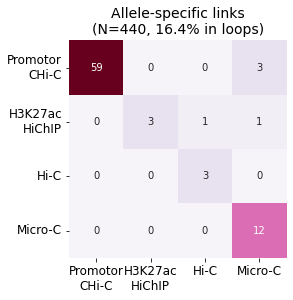

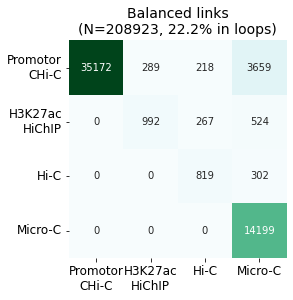

In [145]:
plt.figure(figsize = (4, 4))
plt.title(f'Allele-specific links\n(N={len(links_allele_specific)}, {round(len(np.unique(list(as_links_in_pchic) + list(as_links_in_hichip) + list(as_links_in_hic) + list(as_links_in_microc))) / len(links_allele_specific) * 100, 1)}% in loops)', fontsize = 14)
sns.heatmap(as_links_in_loops, square = True, annot = True, fmt = 'g', cbar = 0, cmap = 'PuRd', vmax = 25)
plt.xticks(np.arange(4)+0.5, ['Promotor\nCHi-C', 'H3K27ac\nHiChIP', 'Hi-C', 'Micro-C'], fontsize = 12)
plt.yticks(np.arange(4)+0.5, ['Promotor\nCHi-C', 'H3K27ac\nHiChIP', 'Hi-C', 'Micro-C'], rotation = 0, fontsize = 12)
plt.savefig('/DATA/users/m.magnitov/hap_phen/figures/links_in_loops_allele_specific.pdf', bbox_inches = 'tight')
plt.show()

plt.figure(figsize = (4, 4))
plt.title(f'Balanced links\n(N={len(links_balanced)}, {round(len(np.unique(list(bal_links_in_pchic) + list(bal_links_in_hichip) + list(bal_links_in_hic) + list(bal_links_in_microc))) / len(links_balanced) * 100, 1)}% in loops)', fontsize = 14)
sns.heatmap(bal_links_in_loops, square = True, annot = True, fmt = 'g', cbar = 0, cmap = 'BuGn', vmax = 25000)
plt.xticks(np.arange(4)+0.5, ['Promoter\nCHi-C', 'H3K27ac\nHiChIP', 'Hi-C', 'Micro-C'], fontsize = 12)
plt.yticks(np.arange(4)+0.5, ['Promoter\nCHi-C', 'H3K27ac\nHiChIP', 'Hi-C', 'Micro-C'], rotation = 0, fontsize = 12)
plt.savefig('/DATA/users/m.magnitov/hap_phen/figures/links_in_loops_balanced.pdf', bbox_inches = 'tight')
plt.show()

## Overlap of links in loops with TADs

In [680]:
def get_tss_positions(links):
    tss_starts, tss_ends = [], []
    for gene in links[['chrom_gene', 'start_gene', 'end_gene', 'strand_gene']].values:
        if gene[-1] == '+':
            tss_start = gene[1]-2500
            tss_end = gene[1]+2500
        else:
            tss_start = gene[2]-2500
            tss_end = gene[2]+2500
        tss_starts.append(tss_start)
        tss_ends.append(tss_end)
    links['start_tss_gene'] = tss_starts
    links['end_tss_gene'] = tss_ends
    return(links)

def overlap_links_and_tads(links, tads):
    links = get_tss_positions(links)
    
    overlap_links_tads_peaks = bioframe.overlap(links, tads, 
                                                cols1 = ['chrom_peak', 'start_peak', 'end_peak'], 
                                                cols2 = ['chrom_tad', 'start_tad', 'end_tad'],
                                                suffixes = ['', '_peak'], return_overlap = True)
    overlap_links_tads_genes = bioframe.overlap(overlap_links_tads_peaks, tads, 
                                                cols1 = ['chrom_gene', 'start_gene', 'end_gene'], 
                                                cols2 = ['chrom_tad', 'start_tad', 'end_tad'],
                                                suffixes = ['', '_gene'], return_overlap = True)
    overlap_links_tads = bioframe.overlap(overlap_links_tads_genes, tads, 
                                          cols1 = ['chrom_gene', 'start_tss_gene', 'end_tss_gene'], 
                                          cols2 = ['chrom_tad', 'start_tad', 'end_tad'],
                                          suffixes = ['', '_tss'], return_overlap = True)

    overlap_links_tads['tad_distance'] = np.abs(overlap_links_tads['id_tad_peak']-overlap_links_tads['id_tad_tss'])

    columns_to_drop = ['start_tss_gene', 'end_tss_gene', 
                       'chrom_tad_peak', 'start_tad_peak', 'end_tad_peak', 'id_tad_peak', 'overlap_start_peak', 'overlap_end_peak', 
                       'chrom_tad_gene', 'start_tad_gene', 'end_tad_gene', 'id_tad_gene', 'overlap_start_gene', 'overlap_end_gene',
                       'chrom_tad_tss', 'start_tad_tss', 'end_tad_tss', 'id_tad_tss', 'overlap_start_tss_gene', 'overlap_end_tss_gene']
    overlap_links_tads = overlap_links_tads.drop(columns_to_drop, axis = 1).sort_values(['link_id', 'tad_distance'])
    overlap_links_tads = overlap_links_tads.drop_duplicates(subset = overlap_links_tads.columns[:-1])
    overlap_links_tads.index = np.arange(len(overlap_links_tads))

    return(overlap_links_tads)

In [702]:
sample = 'NA12878'
links_allele_specific = pd.read_csv(f'links_{sample}_allele_specific.txt', sep = '\t', header = 0)
links_balanced = pd.read_csv(f'links_{sample}_balanced.txt', sep = '\t', header = 0)

tads = pd.read_csv(f'/DATA/users/m.magnitov/hap_phen/HiC/insulation/{sample}.tads.bed', sep = '\t', header = None)
tads.columns = ['chrom_tad', 'start_tad', 'end_tad']
tads['id_tad'] = np.arange(len(tads))

links_allele_specific = overlap_links_and_tads(links_allele_specific, tads)
links_balanced = overlap_links_and_tads(links_balanced, tads)

In [704]:
as_links_in_loops_tads_counts, bal_links_in_loops_tads_counts = [], []

for (method_name, as_links_from_dataset, bal_links_from_dataset) in zip(['Promoter CHi-C', 'H3K27ac HiChIP', 'Hi-C', 'Micro-C'],
                                                                        [list(as_links_in_pchic), list(as_links_in_hichip), list(as_links_in_hic), list(as_links_in_microc)],
                                                                        [list(bal_links_in_pchic), list(bal_links_in_hichip), list(bal_links_in_hic), list(bal_links_in_microc)]):

    as_links_in_loops_tads = np.unique(links_allele_specific[links_allele_specific['link_id'].isin(as_links_from_dataset)]['tad_distance'], return_counts = 1)
    as_links_in_loops_tads = pd.DataFrame(as_links_in_loops_tads).transpose()
    as_links_in_loops_tads.columns = ['tad_distance', 'allele_specific_count']

    bal_links_in_loops_tads = np.unique(links_balanced[links_balanced['link_id'].isin(bal_links_from_dataset)]['tad_distance'], return_counts = 1)
    bal_links_in_loops_tads = pd.DataFrame(bal_links_in_loops_tads).transpose()
    bal_links_in_loops_tads.columns = ['tad_distance', 'balanced_count']
    
    links_in_loops_tads = bal_links_in_loops_tads.merge(as_links_in_loops_tads, how = 'left')
    links_in_loops_tads = links_in_loops_tads.fillna(0)
    
    as_links_in_loops_tads_counts.append([links_in_loops_tads['allele_specific_count'][0], links_in_loops_tads['allele_specific_count'][1], np.sum(links_in_loops_tads['allele_specific_count'][2:])])
    bal_links_in_loops_tads_counts.append([links_in_loops_tads['balanced_count'][0], links_in_loops_tads['balanced_count'][1], np.sum(links_in_loops_tads['balanced_count'][2:])])

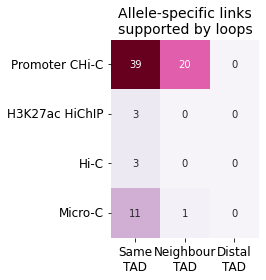

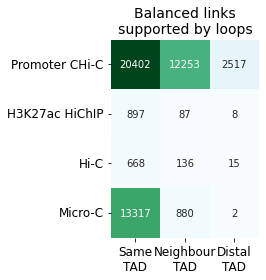

In [705]:
plt.figure(figsize = (3.8, 4))
plt.title('Allele-specific links\nsupported by loops', fontsize = 14)
sns.heatmap(data = as_links_in_loops_tads_counts, 
            annot = True, fmt = '.0f', cbar = 0, cmap = 'PuRd',
            xticklabels = ['Same\nTAD', 'Neighbour\nTAD', 'Distal\nTAD'], 
            yticklabels = ['Promoter CHi-C', 'H3K27ac HiChIP', 'Hi-C', 'Micro-C'])
plt.xticks(rotation = 0, fontsize = 12)
plt.yticks(rotation = 0, fontsize = 12)
plt.tight_layout()
plt.savefig('/DATA/users/m.magnitov/hap_phen/figures/links_supported_by_3d_allele_specific_TADs_quantification_detailed.pdf', bbox_inches = 'tight')
plt.show()

plt.figure(figsize = (3.8, 4))
plt.title('Balanced links\nsupported by loops', fontsize = 14)
sns.heatmap(data = bal_links_in_loops_tads_counts,
            annot = True, fmt = '.0f', cbar = 0, cmap = 'BuGn',
            xticklabels = ['Same\nTAD', 'Neighbour\nTAD', 'Distal\nTAD'], 
            yticklabels = ['Promoter CHi-C', 'H3K27ac HiChIP', 'Hi-C', 'Micro-C'])
plt.xticks(rotation = 0, fontsize = 12)
plt.yticks(rotation = 0, fontsize = 12)
plt.tight_layout()
plt.savefig('/DATA/users/m.magnitov/hap_phen/figures/links_supported_by_3d_balanced_TADs_quantification_detailed.pdf', bbox_inches = 'tight')
plt.show()

## All links in TADs

In [707]:
tad_distances_counts_all_samples = {}
for sample in ['NA12878', 'NA18983', 'HG01241', 'HG02601', 'HG03464']:
    links_allele_specific = pd.read_csv(f'/DATA/users/m.magnitov/hap_phen/links/links_{sample}_allele_specific.txt', sep = '\t', header = 0)
    links_balanced = pd.read_csv(f'/DATA/users/m.magnitov/hap_phen/links/links_{sample}_balanced.txt', sep = '\t', header = 0)

    tads = pd.read_csv(f'/DATA/users/m.magnitov/hap_phen/HiC/insulation/{sample}.tads.bed', sep = '\t', header = None)
    tads.columns = ['chrom_tad', 'start_tad', 'end_tad']
    tads['id_tad'] = np.arange(len(tads))

    overlap_as_links_and_tads = overlap_links_and_tads(links_allele_specific, tads)
    overlap_bal_links_and_tads = overlap_links_and_tads(links_balanced, tads)

    tad_distances_balanced = pd.DataFrame(np.unique(overlap_bal_links_and_tads['tad_distance'], return_counts = 1)).transpose()
    tad_distances_allele_specific = pd.DataFrame(np.unique(overlap_as_links_and_tads['tad_distance'], return_counts = 1)).transpose()

    tad_distances_counts = tad_distances_balanced.merge(tad_distances_allele_specific, on = [0], how = 'outer').replace(np.nan, 0)
    tad_distances_counts.columns = ['tad_distance', 'balanced', 'allele_specific']
    tad_distances_counts['allele_specific'] = [int(x) for x in tad_distances_counts['allele_specific']]
    tad_distances_counts['allele_specific'] = tad_distances_counts['allele_specific']/sum(tad_distances_counts['allele_specific'])
    tad_distances_counts['balanced'] = tad_distances_counts['balanced']/sum(tad_distances_counts['balanced'])

    tads_as_same = tad_distances_counts['allele_specific'][0]
    tads_as_distal = np.sum(tad_distances_counts['allele_specific'][1:])
    tads_bal_same = tad_distances_counts['balanced'][0]
    tads_bal_distal = np.sum(tad_distances_counts['balanced'][1:])

    tad_distances_counts_all_samples[f'{sample}_as'] = [tads_as_same, tads_as_distal]
    tad_distances_counts_all_samples[f'{sample}_bal'] = [tads_bal_same, tads_bal_distal]

print(pd.DataFrame(tad_distances_counts_all_samples))

   NA12878_as  NA12878_bal  NA18983_as  NA18983_bal  HG01241_as  HG01241_bal  \
0    0.661364     0.482058    0.632867     0.457689    0.719626     0.459792   
1    0.338636     0.517942    0.367133     0.542311    0.280374     0.540208   

   HG02601_as  HG02601_bal  HG03464_as  HG03464_bal  
0    0.681934     0.478177    0.625626     0.462733  
1    0.318066     0.521823    0.374374     0.537267  


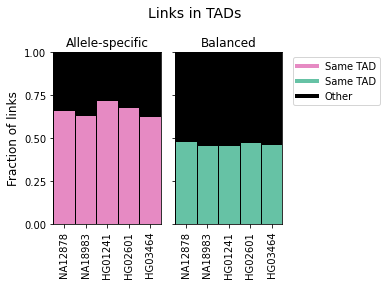

In [709]:
plt.figure(figsize = (5.5, 4))
plt.suptitle('Links in TADs', fontsize = 14)
    
plt.subplot(121)
plt.title('Allele-specific', fontsize = 12)
for i, sample in enumerate(['NA12878', 'NA18983', 'HG01241', 'HG02601', 'HG03464']):
    plt.bar([i, i], [1, tad_distances_counts_all_samples[f'{sample}_as'][0]],
            color = ['k', '#E68AC3'], edgecolor = 'k', width = 1)
plt.xticks(np.arange(5), ['NA12878', 'NA18983', 'HG01241', 'HG02601', 'HG03464'], rotation = 90)
plt.yticks([0, 0.25, 0.5, 0.75, 1])
plt.xlim((-0.5, 4.5))
plt.ylim((0, 1))
plt.ylabel('Fraction of links', fontsize = 12)
    
plt.subplot(122)
plt.title('Balanced', fontsize = 12)
for i, sample in enumerate(['NA12878', 'NA18983', 'HG01241', 'HG02601', 'HG03464']):
    plt.bar([i, i], [1, tad_distances_counts_all_samples[f'{sample}_bal'][0]],
            color = ['k', '#66C2A5'], edgecolor = 'k', width = 1)
plt.xticks(np.arange(5), ['NA12878', 'NA18983', 'HG01241', 'HG02601', 'HG03464'], rotation = 90)
plt.yticks([0, 0.25, 0.5, 0.75, 1], [])
plt.xlim((-0.5, 4.5))
plt.ylim((0, 1))

custom_lines = [Line2D([0], [0], color='#E68AC3', lw=4),
                Line2D([0], [0], color='#66C2A5', lw=4),
                Line2D([0], [0], color='k', lw=4)]
plt.legend(custom_lines, ['Same TAD', 'Same TAD', 'Other'], bbox_to_anchor = (1.05, 1))
    
plt.tight_layout()
plt.savefig('/DATA/users/m.magnitov/hap_phen/figures/links_all_in_TADs_quantification.pdf', bbox_inches = 'tight')
plt.show()

## Number of links

In [710]:
links_stats = []
for sample in ['NA12878', 'NA18983', 'HG01241', 'HG02601', 'HG03464']:
    links_allele_specific = pd.read_csv(f'links_{sample}_allele_specific.txt', sep = '\t', header = 0)
    links_balanced = pd.read_csv(f'links_{sample}_balanced.txt', sep = '\t', header = 0)
    
    tads = pd.read_csv(f'/DATA/users/m.magnitov/hap_phen/HiC/insulation/{sample}.tads.bed', sep = '\t', header = None)
    tads.columns = ['chrom_tad', 'start_tad', 'end_tad']
    tads['id_tad'] = np.arange(len(tads))
    
    # Overlap links with TADs
    links_allele_specific = overlap_links_and_tads(links_allele_specific, tads)
    links_balanced = overlap_links_and_tads(links_balanced, tads)
    
    links_stats.append([len(links_allele_specific), len(links_allele_specific[links_allele_specific['tad_distance'] == 0]),
                        len(links_balanced), len(links_balanced[links_balanced['tad_distance'] == 0])])

links_stats = pd.DataFrame(links_stats)
links_stats.index = ['NA12878', 'NA18983', 'HG01241', 'HG02601', 'HG03464']
links_stats.columns = ['Allele-specific', 'Allele-specific same TAD', 'Balanced', 'Balanced same TAD']
links_stats

,Allele-specific,Allele-specific same TAD,Balanced,Balanced same TAD
NA12878,440,291,208923,100713
NA18983,572,362,206909,94700
HG01241,428,308,271995,125061
HG02601,393,268,192546,92071
HG03464,1397,874,364024,168446


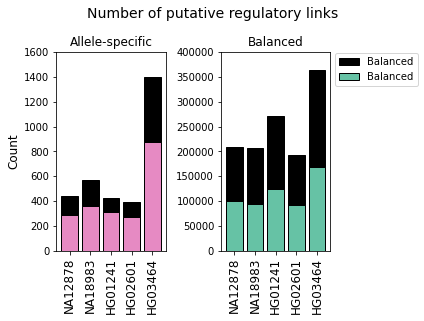

In [711]:
plt.figure(figsize = (6, 4.5))
plt.suptitle('Number of putative regulatory links', fontsize = 14)

plt.subplot(121)
plt.title('Allele-specific', fontsize = 12)
plt.bar(np.arange(5), links_stats['Allele-specific'], color = 'k', edgecolor = 'k', label = 'Allele-specific')
plt.bar(np.arange(5), links_stats['Allele-specific same TAD'], color = '#E68AC3', edgecolor = 'k', label = 'Allele-specific')
plt.xticks(np.arange(5), ['NA12878', 'NA18983', 'HG01241', 'HG02601', 'HG03464'], fontsize = 12, rotation = 90)
plt.ylabel('Count', fontsize = 12)
plt.ylim((0, 1600))

plt.subplot(122)
plt.title('Balanced', fontsize = 12)
plt.bar(np.arange(5), links_stats['Balanced'], color = 'k', edgecolor = 'k', label = 'Balanced')
plt.bar(np.arange(5), links_stats['Balanced same TAD'], color = '#66C2A5', edgecolor = 'k', label = 'Balanced')
plt.ylim((0, 400000))
plt.xticks(np.arange(5), ['NA12878', 'NA18983', 'HG01241', 'HG02601', 'HG03464'], fontsize = 12, rotation = 90)

plt.legend(bbox_to_anchor = (1, 1.02))
plt.tight_layout()
plt.savefig('/DATA/users/m.magnitov/hap_phen/figures/links_number.pdf', bbox_inches = 'tight')
plt.show()

## Distance of links

In [681]:
links_allele_specific_same_tad_distances, links_balanced_same_tad_distances = [], []
links_allele_specific_other_distances, links_balanced_other_distances = [], []
    
for sample in ['NA12878', 'NA18983', 'HG01241', 'HG02601', 'HG03464']:
    links_allele_specific = pd.read_csv(f'links_{sample}_allele_specific.txt', sep = '\t', header = 0)
    links_balanced = pd.read_csv(f'links_{sample}_balanced.txt', sep = '\t', header = 0)
    
    tads = pd.read_csv(f'/DATA/users/m.magnitov/hap_phen/HiC/insulation/{sample}.tads.bed', sep = '\t', header = None)
    tads.columns = ['chrom_tad', 'start_tad', 'end_tad']
    tads['id_tad'] = np.arange(len(tads))
    
    # Overlap links with TADs
    links_allele_specific = overlap_links_and_tads(links_allele_specific, tads)
    links_balanced = overlap_links_and_tads(links_balanced, tads)
    
    # Extract links distances
    links_allele_specific_same_tad = links_allele_specific[links_allele_specific['tad_distance'] == 0]
    links_allele_specific_other = links_allele_specific[links_allele_specific['tad_distance'] != 0]
    links_allele_specific_same_tad_distances = links_allele_specific_same_tad_distances + list(links_allele_specific_same_tad['distance'])
    links_allele_specific_other_distances = links_allele_specific_other_distances + list(links_allele_specific_other['distance'])
    
    links_balanced_same_tad = links_balanced[links_balanced['tad_distance'] == 0]
    links_balanced_other = links_balanced[links_balanced['tad_distance'] != 0]
    links_balanced_same_tad_distances = links_balanced_same_tad_distances + list(links_balanced_same_tad['distance'])
    links_balanced_other_distances = links_balanced_other_distances + list(links_balanced_other['distance'])

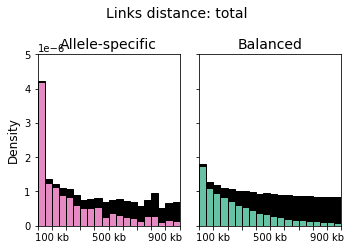

In [682]:
plt.figure(figsize = (5, 3.5))
plt.suptitle('Links distance: total', fontsize = 14)

plt.subplot(121)
plt.title('Allele-specific', fontsize = 14)
plt.hist([links_allele_specific_same_tad_distances, links_allele_specific_other_distances], 
          stacked = True, color = ['#E68AC3', 'k'], edgecolor = 'k', bins = 20, density = True, linewidth = 1)
plt.xlim((0, 1000000))
plt.xticks([0, 100000, 200000, 300000, 400000, 500000, 600000, 700000, 800000, 900000, 1000000], 
           ['', '100 kb', '', '', '', '500 kb', '', '', '', '900 kb', ''])
plt.ylabel('Density', fontsize = 12)
plt.xlim((0, 1000000))
plt.ylim((0, 0.000005))

plt.subplot(122)
plt.title('Balanced', fontsize = 14)
plt.hist([links_balanced_same_tad_distances, links_balanced_other_distances], 
          stacked = True, color = ['#66C2A5', 'k'], edgecolor = 'k', bins = 20, density = True, linewidth = 1)
plt.xlim((0, 1000000))
plt.xticks([0, 100000, 200000, 300000, 400000, 500000, 600000, 700000, 800000, 900000, 1000000], 
           ['', '100 kb', '', '', '', '500 kb', '', '', '', '900 kb', ''])
plt.yticks(np.array([0, 1, 2, 3, 4, 5])/1000000, [])
plt.xlim((0, 1000000))
plt.ylim((0, 0.000005))

plt.tight_layout()
plt.savefig(f'/DATA/users/m.magnitov/hap_phen/figures/links_same_tad_distance_total.pdf', bbox_inches = 'tight')
plt.show()

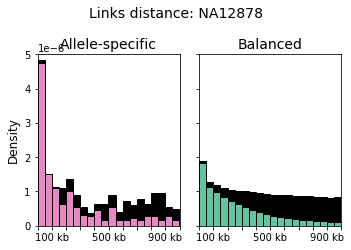

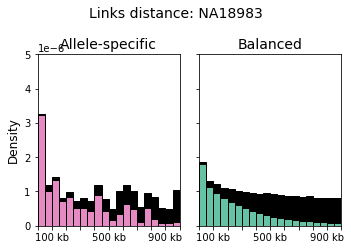

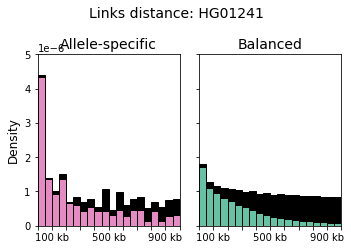

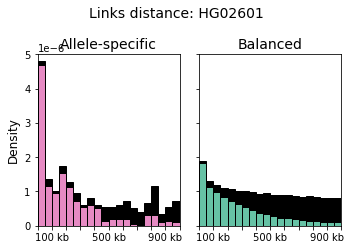

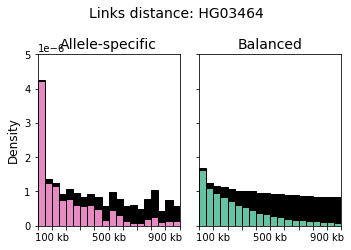

In [683]:
for sample in ['NA12878', 'NA18983', 'HG01241', 'HG02601', 'HG03464']:
    links_allele_specific = pd.read_csv(f'links_{sample}_allele_specific.txt', sep = '\t', header = 0)
    links_balanced = pd.read_csv(f'links_{sample}_balanced.txt', sep = '\t', header = 0)
    
    tads = pd.read_csv(f'/DATA/users/m.magnitov/hap_phen/HiC/insulation/{sample}.tads.bed', sep = '\t', header = None)
    tads.columns = ['chrom_tad', 'start_tad', 'end_tad']
    tads['id_tad'] = np.arange(len(tads))
    
    # Overlap links with TADs
    links_allele_specific = overlap_links_and_tads(links_allele_specific, tads)
    links_balanced = overlap_links_and_tads(links_balanced, tads)
    
    # Extract links distances
    links_allele_specific_same_tad_distances, links_balanced_same_tad_distances = [], []
    links_allele_specific_other_distances, links_balanced_other_distances = [], []
    
    links_allele_specific_same_tad = links_allele_specific[links_allele_specific['tad_distance'] == 0]
    links_allele_specific_other = links_allele_specific[links_allele_specific['tad_distance'] != 0]
    links_allele_specific_same_tad_distances = links_allele_specific_same_tad_distances + list(links_allele_specific_same_tad['distance'])
    links_allele_specific_other_distances = links_allele_specific_other_distances + list(links_allele_specific_other['distance'])
    
    links_balanced_same_tad = links_balanced[links_balanced['tad_distance'] == 0]
    links_balanced_other = links_balanced[links_balanced['tad_distance'] != 0]
    links_balanced_same_tad_distances = links_balanced_same_tad_distances + list(links_balanced_same_tad['distance'])
    links_balanced_other_distances = links_balanced_other_distances + list(links_balanced_other['distance'])

    # Plot
    plt.figure(figsize = (5, 3.5))
    plt.suptitle(f'Links distance: {sample}', fontsize = 14)

    plt.subplot(121)
    plt.title('Allele-specific', fontsize = 14)
    plt.hist([links_allele_specific_same_tad_distances, links_allele_specific_other_distances], 
             stacked = True, color = ['#E68AC3', 'k'], edgecolor = 'k', bins = 20, density = True, linewidth = 1)
    plt.xlim((0, 1000000))
    plt.xticks([0, 100000, 200000, 300000, 400000, 500000, 600000, 700000, 800000, 900000, 1000000], 
               ['', '100 kb', '', '', '', '500 kb', '', '', '', '900 kb', ''])
    plt.ylabel('Density', fontsize = 12)
    plt.xlim((0, 1000000))
    plt.ylim((0, 0.000005))

    plt.subplot(122)
    plt.title('Balanced', fontsize = 14)
    plt.hist([links_balanced_same_tad_distances, links_balanced_other_distances], 
             stacked = True, color = ['#66C2A5', 'k'], edgecolor = 'k', bins = 20, density = True, linewidth = 1)
    plt.xlim((0, 1000000))
    plt.xticks([0, 100000, 200000, 300000, 400000, 500000, 600000, 700000, 800000, 900000, 1000000], 
               ['', '100 kb', '', '', '', '500 kb', '', '', '', '900 kb', ''])
    plt.yticks(np.array([0, 1, 2, 3, 4, 5])/1000000, [])
    plt.xlim((0, 1000000))
    plt.ylim((0, 0.000005))

    plt.tight_layout()
    plt.savefig(f'/DATA/users/m.magnitov/hap_phen/figures/links_same_tad_distance_{sample}.pdf', bbox_inches = 'tight')
    plt.show()